# HTFRS Fase C: Modelo Completo con Sellos Chilenos



In [ ]:
import numpy as np
import pandas as pd
import os
import sys
import pickle
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split

# Parámetros del paper
BETA = 0.6          # CF weight (paper optimal)
GAMMAS = [0, 0.1, 0.2, 0.3, 0.5, 0.8]
K_RECS = 10
TEST_SIZE = 0.2
RANDOM_STATE = 42

print('Setup listo')

Setup listo


## 1. Cargar resultados de Fases A y B

In [ ]:
with open('htfrs_cf_output.pkl', 'rb') as f:
    cf_output = pickle.load(f)

with open('htfrs_food_output.pkl', 'rb') as f:
    food_output = pickle.load(f)

user_recommendations_cf = cf_output['user_recommendations_cf']
user_predictions_food = food_output.get('user_predictions_food', {})
user_recommendations_food = food_output['user_recommendations_food']
user_mean_rating = cf_output['user_mean_rating']
item_mean_rating = food_output['item_mean_rating']

print(f'Usuarios con recomendaciones CF: {len(user_recommendations_cf)}')
print(f'Usuarios con predicciones food: {len(user_predictions_food)}')
print(f'Métricas CF: {cf_output["metrics_cf"]}')
print(f'Métricas food: {food_output["metrics_food"]}')

Usuarios con recomendaciones CF: 41698
Usuarios con predicciones food: 32947
Métricas CF: {'P@K': np.float64(0.0034414120581322846), 'R@K': np.float64(0.01414742035703996), 'F1@K': np.float64(0.004341025770404397), 'nDCG@K': np.float64(0.017175734230972857), 'MAP@K': np.float64(0.006059374778737818), 'S@K': np.float64(1.1375125905319199), 'SS@K': np.float64(0.3920763585783492)}
Métricas food: {'P@K': np.float64(0.00022156797280480775), 'R@K': np.float64(0.0007285271839470768), 'F1@K': np.float64(0.0002466900729864775), 'nDCG@K': np.float64(0.0009783245012212464), 'MAP@K': np.float64(0.0002919068110511945), 'S@K': np.float64(0.8781072631802592), 'SS@K': np.float64(0.5460922086988192)}


In [ ]:
# Cargar datos para evaluación
try:
    import kagglehub
    path = kagglehub.dataset_download('irkaal/foodcom-recipes-and-reviews')
    reviews = pd.read_csv(os.path.join(path, 'reviews.csv'))
except Exception:
    reviews = pd.read_csv('../Dataset_recetas/reviews.csv')

try:
    import gdown
    url = 'https://drive.google.com/uc?id=1Rl8XowC9N6cxrdiPvH4wToFUvZrrBqRG'
    gdown.download(url, 'recipes_final_consolidado.csv', quiet=True)
    recipes = pd.read_csv('recipes_final_consolidado.csv')
except Exception:
    recipes = pd.read_csv('../Dataset_recetas/recipes_final_consolidado.csv')

recipes['ExtractedServingSize'] = recipes['ExtractedServingSize'].str.extract(r'\((.*?)\)').astype(float)
recipes = recipes[recipes['ExtractedServingSize'] > 0].copy()
user_counts = reviews['AuthorId'].value_counts()
valid_users = user_counts[user_counts > 1].index
reviews_filtrado = reviews[reviews['AuthorId'].isin(valid_users)].copy()
valid_recipes = set(recipes['RecipeId'])
reviews_filtrado = reviews_filtrado[reviews_filtrado['RecipeId'].isin(valid_recipes)].copy()

# Sellos
recipes['IsHighCalories'] = ((recipes['Calories'] / recipes['ExtractedServingSize']) * 100) >= 275
recipes['IsHighSugar'] = ((recipes['SugarContent'] / recipes['ExtractedServingSize']) * 100) >= 10
recipes['IsHighSaturatedFat'] = ((recipes['SaturatedFatContent'] / recipes['ExtractedServingSize']) * 100) >= 4
recipes['IsHighSodium'] = ((recipes['SodiumContent'] / recipes['ExtractedServingSize']) * 100) >= 400
recipes['num_sellos'] = recipes[['IsHighCalories', 'IsHighSugar', 'IsHighSaturatedFat', 'IsHighSodium']].sum(axis=1).astype(int)
recipe_sellos_dict = dict(zip(recipes['RecipeId'], recipes['num_sellos']))

# Health Factor basado en sellos
recipe_hf = {rid: 1.0 - ns / 4.0 for rid, ns in recipe_sellos_dict.items()}

# Split (mismo que los otros notebooks)
train_df, test_df = train_test_split(reviews_filtrado, test_size=TEST_SIZE, random_state=RANDOM_STATE)

train_items_per_user = defaultdict(set)
for row in train_df[['AuthorId', 'RecipeId']].itertuples(index=False):
    train_items_per_user[row[0]].add(row[1])

global_mean = train_df['Rating'].mean()
print(f'Datos cargados. Train: {len(train_df)}, Test: {len(test_df)}')

Using Colab cache for faster access to the 'foodcom-recipes-and-reviews' dataset.
Datos cargados. Train: 959671, Test: 239918


## 2. Preference Rating (Eq. 11) + Health Re-ranking (Eq. 13)

In [ ]:
def htfrs_recommend(user_id, user_recommendations_cf, user_predictions_food,
                    recipe_hf, train_items, user_mean_rating, item_mean_rating,
                    global_mean, beta=BETA, gamma=0.2, k=K_RECS):
    """
    HTFRS completo:
    Eq. 11: p_pref = beta * p_cf + (1-beta) * p_food
    Eq. 13: p_final = (1-gamma) * p_pref + gamma * HF
    """
    # CF: usamos las recomendaciones como ranking (score decreciente)
    cf_recs = user_recommendations_cf.get(user_id, [])
    food_preds = user_predictions_food.get(user_id, {})

    # Construir scores CF a partir del ranking (top-1 = score más alto)
    cf_scores = {}
    mean_u = user_mean_rating.get(user_id, global_mean)
    for rank, item_id in enumerate(cf_recs):
        cf_scores[item_id] = mean_u + (len(cf_recs) - rank) / len(cf_recs)

    # Unión de items
    all_items = set(cf_scores.keys()) | set(food_preds.keys())
    seen = train_items.get(user_id, set())

    scores = {}
    for item_id in all_items:
        if item_id in seen:
            continue

        p_cf = cf_scores.get(item_id)
        p_food = food_preds.get(item_id)

        if p_cf is not None and p_food is not None:
            p_pref = beta * p_cf + (1 - beta) * p_food
        elif p_cf is not None:
            p_pref = p_cf
        else:
            p_pref = p_food

        hf = recipe_hf.get(item_id, 0.5)
        p_final = (1 - gamma) * p_pref + gamma * hf * 5
        scores[item_id] = p_final

    sorted_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [item_id for item_id, _ in sorted_items[:k]]


print('Funciones de ensamblaje definidas.')

Funciones de ensamblaje definidas.


## 3. Sensitivity Analysis de γ

In [ ]:
# === evaluation_utils (inline para Colab) ===
import numpy as np

RELEVANCE_THRESHOLD = 4

def get_relevant_items(test_df, user_id, threshold=RELEVANCE_THRESHOLD):
    user_test = test_df[test_df['AuthorId'] == user_id]
    return set(user_test[user_test['Rating'] >= threshold]['RecipeId'])

def precision_at_k(recommended, relevant, k=10):
    return len(set(recommended[:k]) & set(relevant)) / k

def recall_at_k(recommended, relevant, k=10):
    rel_set = set(relevant)
    if len(rel_set) == 0:
        return 0.0
    return len(set(recommended[:k]) & rel_set) / len(rel_set)

def f1_at_k(recommended, relevant, k=10):
    p = precision_at_k(recommended, relevant, k)
    r = recall_at_k(recommended, relevant, k)
    if p + r == 0:
        return 0.0
    return 2 * p * r / (p + r)

def _dcg_at_k(relevances, k):
    relevances = np.asarray(relevances)[:k]
    if relevances.size:
        return np.sum((2**relevances - 1) / np.log2(np.arange(2, relevances.size + 2)))
    return 0.0

def ndcg_at_k(recommended, relevant, k=10):
    relevances = [1 if r in relevant else 0 for r in recommended[:k]]
    dcg = _dcg_at_k(relevances, k)
    ideal = _dcg_at_k(sorted(relevances, reverse=True), k)
    return dcg / ideal if ideal > 0 else 0.0

def average_precision_at_k(recommended, relevant, k=10):
    hits = 0
    sum_prec = 0.0
    rel_set = set(relevant)
    for i, item in enumerate(recommended[:k]):
        if item in rel_set:
            hits += 1
            sum_prec += hits / (i + 1)
    return sum_prec / min(len(rel_set), k) if rel_set else 0.0

def sellos_at_k(recommended, recipe_sellos_dict, k=10):
    sellos = [recipe_sellos_dict.get(r, 0) for r in recommended[:k]]
    return np.mean(sellos) if sellos else 0.0

def sello_free_at_k(recommended, recipe_sellos_dict, k=10):
    sellos = [recipe_sellos_dict.get(r, 0) for r in recommended[:k]]
    return np.mean([1 if s == 0 else 0 for s in sellos]) if sellos else 0.0

def evaluate_recommendations(recommended, relevant, recipe_sellos_dict, k=10):
    return {
        'P@K': precision_at_k(recommended, relevant, k),
        'R@K': recall_at_k(recommended, relevant, k),
        'F1@K': f1_at_k(recommended, relevant, k),
        'nDCG@K': ndcg_at_k(recommended, relevant, k),
        'MAP@K': average_precision_at_k(recommended, relevant, k),
        'S@K': sellos_at_k(recommended, recipe_sellos_dict, k),
        'SS@K': sello_free_at_k(recommended, recipe_sellos_dict, k),
    }

def evaluate_all_users(user_recommendations, test_df, recipe_sellos_dict,
                       k=10, threshold=RELEVANCE_THRESHOLD):
    all_metrics = []
    for user_id, recommended in user_recommendations.items():
        relevant = get_relevant_items(test_df, user_id, threshold)
        metrics = evaluate_recommendations(recommended, relevant, recipe_sellos_dict, k)
        all_metrics.append(metrics)
    if not all_metrics:
        return {}
    return {key: np.mean([m[key] for m in all_metrics]) for key in all_metrics[0]}

# --- Sensitivity Analysis ---
eval_users = set(user_recommendations_cf.keys()) & set(test_df['AuthorId'].unique())
print(f'Usuarios para evaluación: {len(eval_users)}')

results = []

for gamma in GAMMAS:
    print(f'\nEvaluando γ={gamma}...')
    user_recs = {}
    for u in eval_users:
        recs = htfrs_recommend(
            u, user_recommendations_cf, user_predictions_food,
            recipe_hf, train_items_per_user, user_mean_rating,
            item_mean_rating, global_mean,
            beta=BETA, gamma=gamma, k=K_RECS
        )
        if recs:
            user_recs[u] = recs

    metrics = evaluate_all_users(user_recs, test_df, recipe_sellos_dict, k=K_RECS)
    metrics['gamma'] = gamma
    metrics['n_users'] = len(user_recs)
    results.append(metrics)

    print(f'  γ={gamma}: nDCG={metrics.get("nDCG@K", 0):.6f}, '
          f'S@K={metrics.get("S@K", 0):.4f}, SS@K={metrics.get("SS@K", 0):.4f}')

results_df = pd.DataFrame(results)
print('\n=== Tabla de resultados HTFRS-Sellos ===')
print(results_df.to_string(index=False))

Usuarios para evaluación: 41698

Evaluando γ=0...
  γ=0: nDCG=0.013008, S@K=1.0709, SS@K=0.4135

Evaluando γ=0.1...
  γ=0.1: nDCG=0.011087, S@K=0.4567, SS@K=0.7113

Evaluando γ=0.2...
  γ=0.2: nDCG=0.009755, S@K=0.3090, SS@K=0.7968

Evaluando γ=0.3...
  γ=0.3: nDCG=0.008825, S@K=0.2823, SS@K=0.8227

Evaluando γ=0.5...
  γ=0.5: nDCG=0.007549, S@K=0.2310, SS@K=0.8740

Evaluando γ=0.8...
  γ=0.8: nDCG=0.007549, S@K=0.2308, SS@K=0.8741

=== Tabla de resultados HTFRS-Sellos ===
     P@K      R@K     F1@K   nDCG@K    MAP@K      S@K     SS@K  gamma  n_users
0.002532 0.010433 0.003187 0.013008 0.004502 1.070855 0.413511    0.0    41698
0.001962 0.008845 0.002580 0.011087 0.003910 0.456657 0.711324    0.1    41698
0.001684 0.007697 0.002239 0.009755 0.003433 0.309017 0.796822    0.2    41698
0.001480 0.007017 0.002002 0.008825 0.003178 0.282313 0.822675    0.3    41698
0.001206 0.005280 0.001557 0.007549 0.002641 0.230997 0.873963    0.5    41698
0.001206 0.005280 0.001557 0.007549 0.002641 0.2

## 4. Visualizaciones

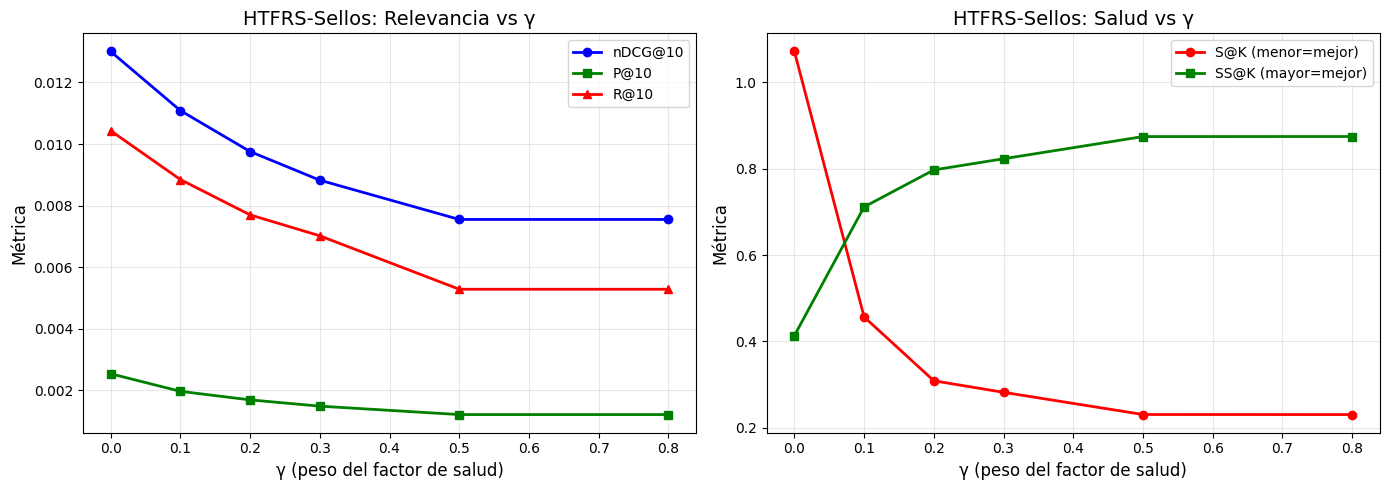

Guardado: sensitivity_gamma_sellos.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: γ vs métricas de relevancia
ax1 = axes[0]
ax1.plot(results_df['gamma'], results_df['nDCG@K'], 'b-o', label='nDCG@10', linewidth=2)
ax1.plot(results_df['gamma'], results_df['P@K'], 'g-s', label='P@10', linewidth=2)
ax1.plot(results_df['gamma'], results_df['R@K'], 'r-^', label='R@10', linewidth=2)
ax1.set_xlabel('γ (peso del factor de salud)', fontsize=12)
ax1.set_ylabel('Métrica', fontsize=12)
ax1.set_title('HTFRS-Sellos: Relevancia vs γ', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: γ vs métricas de salud
ax2 = axes[1]
ax2.plot(results_df['gamma'], results_df['S@K'], 'r-o', label='S@K (menor=mejor)', linewidth=2)
ax2.plot(results_df['gamma'], results_df['SS@K'], 'g-s', label='SS@K (mayor=mejor)', linewidth=2)
ax2.set_xlabel('γ (peso del factor de salud)', fontsize=12)
ax2.set_ylabel('Métrica', fontsize=12)
ax2.set_title('HTFRS-Sellos: Salud vs γ', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sensitivity_gamma_sellos.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: sensitivity_gamma_sellos.png')

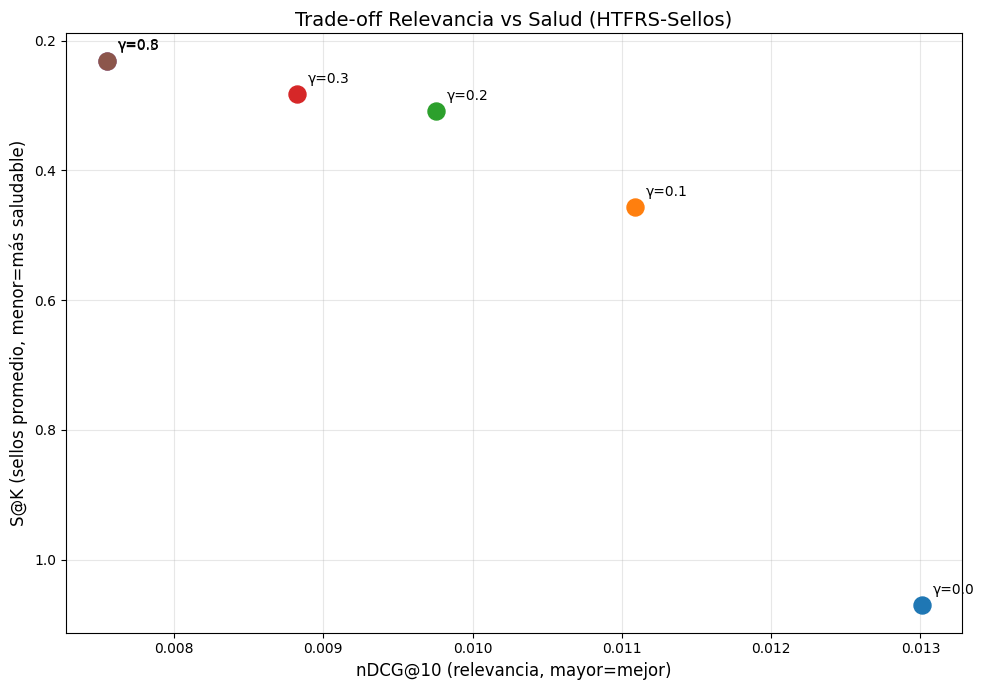

Guardado: tradeoff_relevancia_salud.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

for _, row in results_df.iterrows():
    ax.scatter(row['nDCG@K'], row['S@K'], s=150, zorder=5)
    ax.annotate(f'γ={row["gamma"]}',
                (row['nDCG@K'], row['S@K']),
                xytext=(8, 8), textcoords='offset points', fontsize=10)

ax.set_xlabel('nDCG@10 (relevancia, mayor=mejor)', fontsize=12)
ax.set_ylabel('S@K (sellos promedio, menor=más saludable)', fontsize=12)
ax.set_title('Trade-off Relevancia vs Salud (HTFRS-Sellos)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.invert_yaxis()  # Menor S@K es mejor

plt.tight_layout()
plt.savefig('tradeoff_relevancia_salud.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: tradeoff_relevancia_salud.png')

## 5. Tabla comparativa con todos los modelos

Incluir resultados de los otros notebooks (copiar manualmente después de re-evaluar con protocolo unificado).

In [ ]:
# TODO: Llenar con los resultados reales de cada notebook después de estandarizar
# Los valores de HTFRS-Sellos se toman de results_df

comparison = {
    'Método': [],
    'P@10': [],
    'R@10': [],
    'nDCG@10': [],
    'S@10': [],
    'SS@10': [],
}

# Agregar HTFRS-Sellos para cada γ
for _, row in results_df.iterrows():
    comparison['Método'].append(f'HTFRS-Sellos (γ={row["gamma"]})')
    comparison['P@10'].append(row['P@K'])
    comparison['R@10'].append(row['R@K'])
    comparison['nDCG@10'].append(row['nDCG@K'])
    comparison['S@10'].append(row['S@K'])
    comparison['SS@10'].append(row['SS@K'])

# Paper HTFRS-OMS (Tabla 7, Food.com) — por referencia, NO comparable directamente
comparison['Método'].append('HTFRS-OMS (paper, Tabla 7)*')
comparison['P@10'].append(0.0654)
comparison['R@10'].append(0.0637)
comparison['nDCG@10'].append(0.0453)
comparison['S@10'].append(np.nan)
comparison['SS@10'].append(np.nan)

comparison_df = pd.DataFrame(comparison)
print('=== Tabla Comparativa ===')
print(comparison_df.to_string(index=False))
print('\n* Valores del paper original. Dataset diferente (25K users vs 72K), no directamente comparable.')

comparison_df.to_csv('comparacion_htfrs_sellos.csv', index=False)
print('\nGuardado: comparacion_htfrs_sellos.csv')

=== Tabla Comparativa ===
                     Método     P@10     R@10  nDCG@10     S@10    SS@10
       HTFRS-Sellos (γ=0.0) 0.002532 0.010433 0.013008 1.070855 0.413511
       HTFRS-Sellos (γ=0.1) 0.001962 0.008845 0.011087 0.456657 0.711324
       HTFRS-Sellos (γ=0.2) 0.001684 0.007697 0.009755 0.309017 0.796822
       HTFRS-Sellos (γ=0.3) 0.001480 0.007017 0.008825 0.282313 0.822675
       HTFRS-Sellos (γ=0.5) 0.001206 0.005280 0.007549 0.230997 0.873963
       HTFRS-Sellos (γ=0.8) 0.001206 0.005280 0.007549 0.230846 0.874092
HTFRS-OMS (paper, Tabla 7)* 0.065400 0.063700 0.045300      NaN      NaN

* Valores del paper original. Dataset diferente (25K users vs 72K), no directamente comparable.

Guardado: comparacion_htfrs_sellos.csv


## 6. Gráfico de barras comparativo

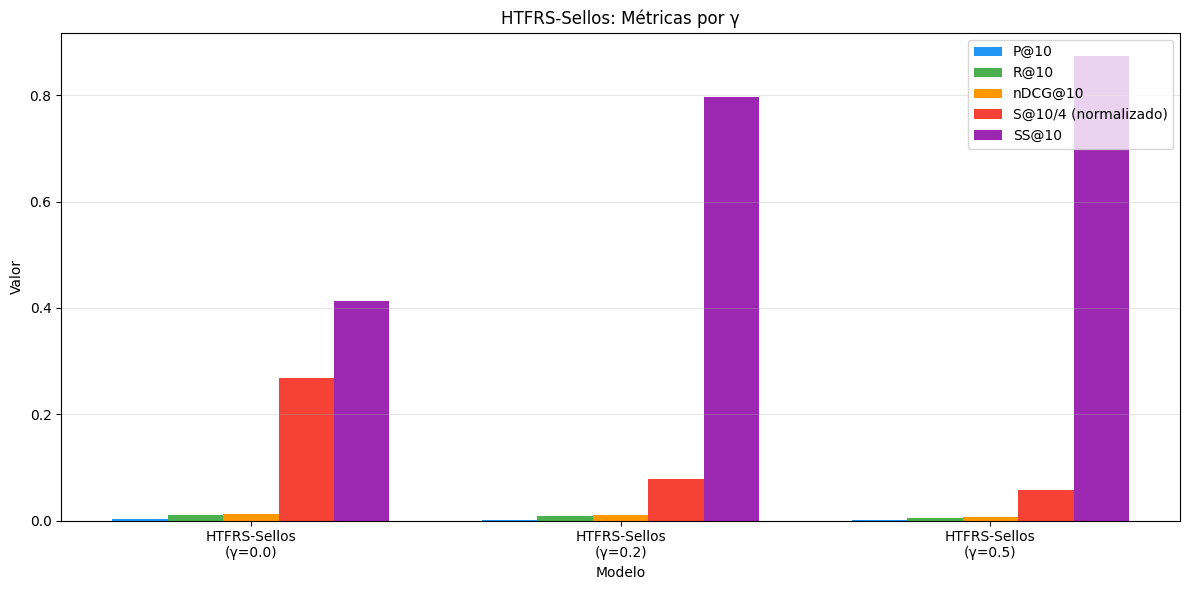

Guardado: comparacion_metricas_htfrs.png


In [ ]:
# Seleccionar los gammas más representativos para el gráfico
key_gammas = [0, 0.2, 0.5]
key_results = results_df[results_df['gamma'].isin(key_gammas)]

methods = [f'HTFRS-Sellos\n(γ={g})' for g in key_results['gamma']]
x = np.arange(len(methods))
width = 0.15

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width*2, key_results['P@K'], width, label='P@10', color='#2196F3')
ax.bar(x - width, key_results['R@K'], width, label='R@10', color='#4CAF50')
ax.bar(x, key_results['nDCG@K'], width, label='nDCG@10', color='#FF9800')
ax.bar(x + width, key_results['S@K'] / 4, width, label='S@10/4 (normalizado)', color='#F44336')
ax.bar(x + width*2, key_results['SS@K'], width, label='SS@10', color='#9C27B0')

ax.set_xlabel('Modelo')
ax.set_ylabel('Valor')
ax.set_title('HTFRS-Sellos: Métricas por γ')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('comparacion_metricas_htfrs.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: comparacion_metricas_htfrs.png')